In [10]:
import os, json, time, random, warnings
import numpy as np
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF:', tf.__version__)
print('MediaPipe:', mp.__version__)
print('OpenCV:', cv2.__version__)

TF: 2.15.0
MediaPipe: 0.10.14
OpenCV: 4.11.0


In [11]:
# ── Paths 
raw_dataset_path = r'C:\Users\rrree\OneDrive\Dataset_1_12'  
processed_path   = r'C:\Users\rrree\ASLproject\digits_processed'
landmarks_path   = r'C:\Users\rrree\ASLproject\digits_landmarks.npz'
model_save_path  = r'C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5'
class_path       = r'C:\Users\rrree\ASLproject\digits_class_indices.json'

# ── Image settings 
image_size       = 128
hand_margin      = 0.20
detection_resize = 640

# ── Classes 
Digits      = [str(d) for d in range(10)]   # ['0', '1', ..., '9']
num_classes = 10

# ── Landmark settings 
num_landmarks = 21          # MediaPipe gives 21 hand keypoints
coords_per_pt = 3           # x, y, z per keypoint
feature_size  = num_landmarks * coords_per_pt   # 63 input features

# ── Augmentation per image 
num_augments  = 5

# ── Training 
batch_size  = 256
epochs      = 100
LR          = 1e-3
val_split   = 0.20

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

os.makedirs(processed_path, exist_ok=True)
os.makedirs(Path(model_save_path).parent, exist_ok=True)

print(f'  Classes      : {num_classes}')
print(f'  Feature size : {feature_size}  (21 keypoints × 3 coords)')
print(f'  Augments/img : {num_augments}')
print(f'  Epochs       : {epochs}')

  Classes      : 10
  Feature size : 63  (21 keypoints × 3 coords)
  Augments/img : 5
  Epochs       : 100


Found 10/10 digit folders: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total images : 5,000


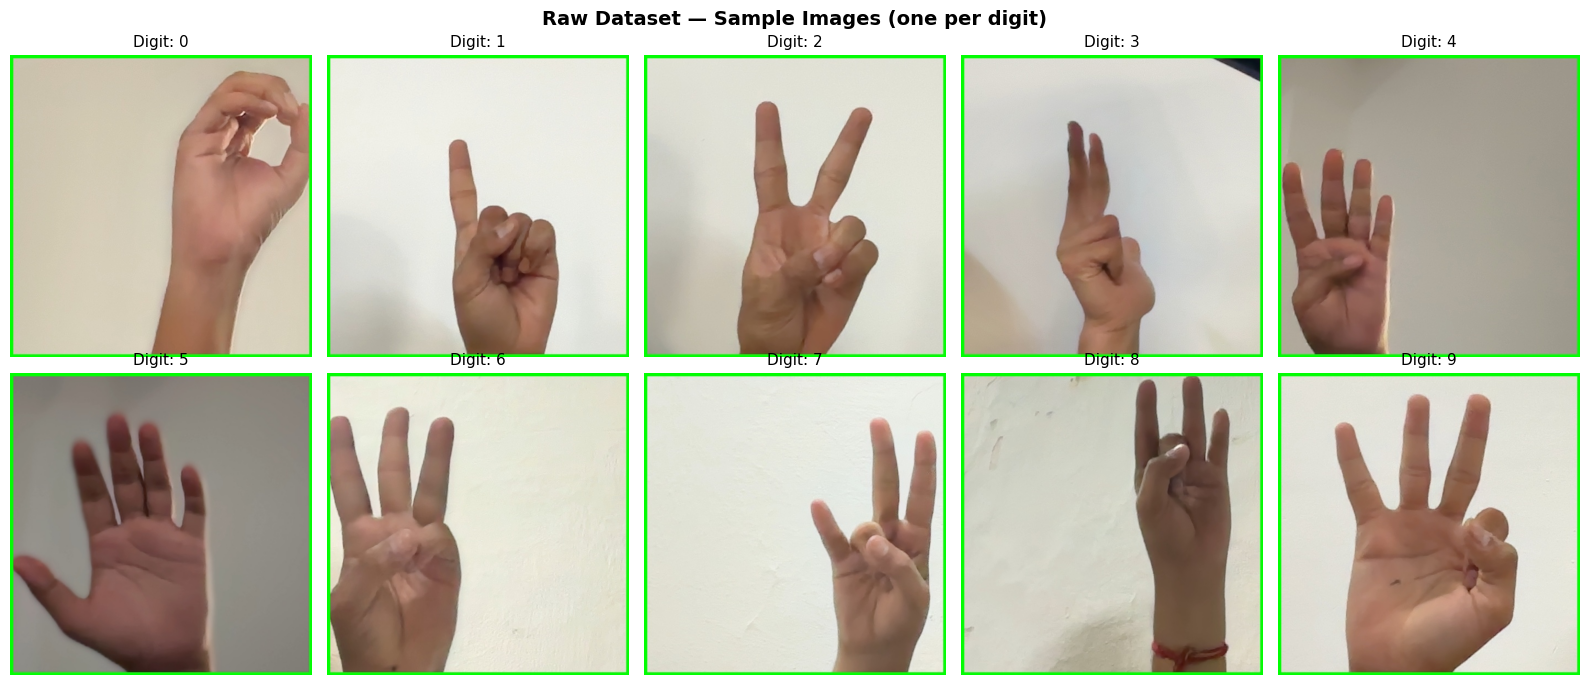

In [12]:
# ── Verify the raw dataset exists and count images ─────────────────────────
raw_root = Path(raw_dataset_path)

if not raw_root.exists():
    raise FileNotFoundError(f'Dataset not found at: {raw_dataset_path}')

found = sorted([d.name for d in raw_root.iterdir()
                if d.is_dir() and d.name in Digits])
total = sum(len(list((raw_root / d).glob('*.*'))) for d in found)

print(f'Found {len(found)}/10 digit folders: {found}')
print(f'Total images : {total:,}')

# ── Preview a sample of raw images ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, digit in zip(axes.flatten(), found):
    imgs = list((raw_root / digit).glob('*.*'))[:1]
    imgs = [p for p in imgs if p.suffix.lower() in image_extensions]
    if imgs:
        ax.imshow(cv2.cvtColor(cv2.imread(str(imgs[0])), cv2.COLOR_BGR2RGB))
        ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')

plt.suptitle('Raw Dataset — Sample Images (one per digit)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
def crop_hand(img_bgr, margin=hand_margin,
              det_resize=detection_resize, out_size=image_size):
    """Detect the hand with MediaPipe, crop around it, and resize."""

    h_orig, w_orig = img_bgr.shape[:2]

    # Down-scale before detection for speed
    scale = 1.0
    if max(h_orig, w_orig) > det_resize:
        scale = det_resize / max(h_orig, w_orig)
        small = cv2.resize(img_bgr, (int(w_orig * scale), int(h_orig * scale)))
    else:
        small = img_bgr

    mp_hands = mp.solutions.hands
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1,
                        min_detection_confidence=0.4) as hands:
        result = hands.process(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))

    if not result.multi_hand_landmarks:
        # No hand found → return full image as fallback
        return cv2.resize(img_bgr, (out_size, out_size)), False

    # Convert normalised landmark coords back to original image pixels
    h_s, w_s = small.shape[:2]
    lms = result.multi_hand_landmarks[0].landmark
    xs  = [int(lm.x * w_s / scale) for lm in lms]
    ys  = [int(lm.y * h_s / scale) for lm in lms]

    # Build bounding box and add margin
    bw = max(xs) - min(xs)
    bh = max(ys) - min(ys)
    x1 = max(0,      min(xs) - int(bw * margin))
    y1 = max(0,      min(ys) - int(bh * margin))
    x2 = min(w_orig, max(xs) + int(bw * margin))
    y2 = min(h_orig, max(ys) + int(bh * margin))

    crop = img_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        crop = img_bgr

    return cv2.resize(crop, (out_size, out_size)), True


print('crop_hand() defined.')

crop_hand() defined.


In [14]:
# ── Crop-and-resize all raw images 
raw_root  = Path(raw_dataset_path)
proc_root = Path(processed_path)

task_pairs = []
for digit in Digits:
    src_dir = raw_root  / digit
    dst_dir = proc_root / digit
    if not src_dir.exists():
        continue
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img_path in src_dir.iterdir():
        if img_path.suffix.lower() in image_extensions:
            task_pairs.append((str(img_path), str(dst_dir / img_path.name)))

already_done = sum(1 for _, d in task_pairs if Path(d).exists())
print(f'Total images : {len(task_pairs):,}')
print(f'Already done : {already_done:,}')
print(f'To process   : {len(task_pairs) - already_done:,}')

counters = {'ok': 0, 'fallback': 0, 'error': 0, 'skip': 0}
t0 = time.time()

for src_str, dst_str in tqdm(task_pairs, desc='Preprocessing', unit='img'):
    if Path(dst_str).exists():
        counters['skip'] += 1
        continue

    img = cv2.imread(src_str)
    if img is None:
        counters['error'] += 1
        continue

    cropped, detected = crop_hand(img)
    cv2.imwrite(dst_str, cropped)
    counters['ok' if detected else 'fallback'] += 1

elapsed = timedelta(seconds=int(time.time() - t0))
print(f'\nDone in {elapsed}')
print(f"   Hand detected  : {counters['ok']:,}")
print(f"   Fallback (full): {counters['fallback']:,}")
print(f"   Errors         : {counters['error']:,}")
print(f"   Skipped (done) : {counters['skip']:,}")

Total images : 5,000
Already done : 0
To process   : 5,000


Preprocessing:   0%|          | 0/5000 [00:00<?, ?img/s]


Done in 0:05:33
   Hand detected  : 4,982
   Fallback (full): 18
   Errors         : 0
   Skipped (done) : 0


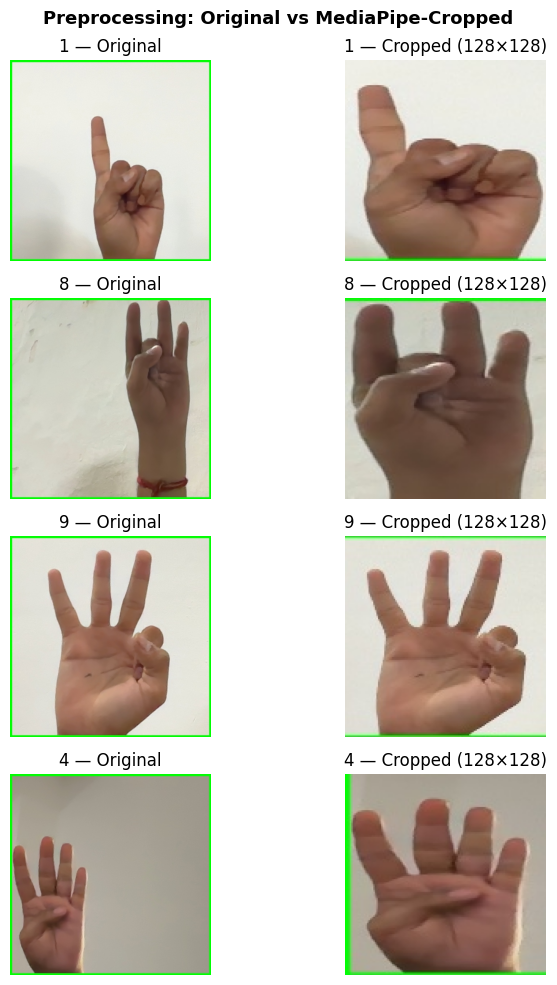

In [15]:
#  Original vs Cropped preview 
sample_digits = random.sample(Digits, min(4, len(Digits)))
fig, axes = plt.subplots(4, 2, figsize=(8, 10))

for row, digit in enumerate(sample_digits):
    raw_imgs  = [p for p in (raw_root  / digit).glob('*.*') if p.suffix.lower() in image_extensions][:1]
    proc_imgs = [p for p in (proc_root / digit).glob('*.*') if p.suffix.lower() in image_extensions][:1]
    if raw_imgs:
        axes[row, 0].imshow(cv2.cvtColor(cv2.imread(str(raw_imgs[0])),  cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f'{digit} — Original')
    if proc_imgs:
        axes[row, 1].imshow(cv2.cvtColor(cv2.imread(str(proc_imgs[0])), cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f'{digit} — Cropped ({image_size}×{image_size})')
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Preprocessing: Original vs MediaPipe-Cropped', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
def augment_image(img_bgr):
    """Apply random augmentation to a BGR image."""

    h, w = img_bgr.shape[:2]

    # Rotation
    angle = random.uniform(-20, 20)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img_bgr, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Brightness & contrast
    alpha = random.uniform(0.4, 1.8)   # contrast
    beta  = random.randint(-40, 40)    # brightness
    img   = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Zoom
    zoom = random.uniform(0.85, 1.15)
    zh, zw = int(h * zoom), int(w * zoom)
    if zoom > 1.0:
        img = cv2.resize(img, (zw, zh))
        y1  = (zh - h) // 2
        x1  = (zw - w) // 2
        img = img[y1:y1+h, x1:x1+w]
    else:
        img = cv2.resize(img, (zw, zh))
        pad_y = (h - zh) // 2
        pad_x = (w - zw) // 2
        img = cv2.copyMakeBorder(img, pad_y, h - zh - pad_y,
                                      pad_x, w - zw - pad_x,
                                      cv2.BORDER_REFLECT)

    # Random channel shift (skin tone / lighting color variation)
    shift = np.random.randint(-40, 40, 3)
    img   = np.clip(img.astype(np.int32) + shift, 0, 255).astype(np.uint8)

    return img


def extract_landmarks(img_bgr, mp_hands_instance):
    """Extract wrist-relative, scale-normalised landmarks from an image."""

    rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result = mp_hands_instance.process(rgb)

    if not result.multi_hand_landmarks:
        return None

    landmarks = result.multi_hand_landmarks[0].landmark

    # Raw coordinates  (21, 3)
    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

    # Translate: subtract wrist (landmark 0)
    coords -= coords[0]

    # Scale: divide by max distance from wrist
    max_dist = np.max(np.linalg.norm(coords, axis=1)) + 1e-6
    coords  /= max_dist

    return coords.flatten()   # (63,)


print('Helper functions defined.')

Helper functions defined.


In [17]:
# ── Extract landmarks from all preprocessed images ─────────────────────────
if Path(landmarks_path).exists():
    print(f'Landmarks already extracted at {landmarks_path}')
    print('Loading...')
    data = np.load(landmarks_path)
    X    = data['X']
    y    = data['y']
    print(f'Loaded: X={X.shape}, y={y.shape}')

else:
    print('Extracting landmarks (augment first, then extract)...')

    proc_root = Path(processed_path)
    X_list, y_list = [], []
    failed = 0

    mp_hands = mp.solutions.hands.Hands(
        static_image_mode        = True,
        max_num_hands            = 1,
        min_detection_confidence = 0.4,
    )

    t0 = time.time()

    for label_idx, digit in enumerate(Digits):
        digit_dir = proc_root / digit
        if not digit_dir.exists():
            print(f'  [WARN] folder not found: {digit_dir}')
            continue

        img_paths = [p for p in digit_dir.iterdir()
                     if p.suffix.lower() in image_extensions]

        for img_path in tqdm(img_paths, desc=f'Digit {digit}', leave=False):
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                continue

            # Augment first, then extract landmarks from each version
            # → model generalises across lighting / rotation / zoom
            versions = [img_bgr] + [augment_image(img_bgr) for _ in range(num_augments)]

            for version in versions:
                features = extract_landmarks(version, mp_hands)
                if features is not None:
                    X_list.append(features)
                    y_list.append(label_idx)
                else:
                    failed += 1

        print(f'  Digit {digit} done — total samples so far: {len(X_list):,}')

    mp_hands.close()

    X = np.array(X_list, dtype=np.float32)   # (N, 63)
    y = np.array(y_list,  dtype=np.int32)     # (N,)

    np.savez_compressed(landmarks_path, X=X, y=y)

    elapsed = timedelta(seconds=int(time.time() - t0))
    print(f'\nDone in {elapsed}')
    print(f'Total samples extracted : {len(X):,}')
    print(f'Failed (no hand found)  : {failed:,}')
    print(f'Saved to: {landmarks_path}')

Extracting landmarks (augment first, then extract)...


Digit 0:   0%|          | 0/500 [00:00<?, ?it/s]

  Digit 0 done — total samples so far: 553


Digit 1:   0%|          | 0/500 [00:00<?, ?it/s]

  Digit 1 done — total samples so far: 1,071


...

  Digit 7 done — total samples so far: 10,574


Digit 8:   0%|          | 0/500 [00:00<?, ?it/s]

  Digit 8 done — total samples so far: 11,882


Digit 9:   0%|          | 0/500 [00:00<?, ?it/s]

  Digit 9 done — total samples so far: 13,747

Done in 0:11:28
Total samples extracted : 13,747
Failed (no hand found)  : 16,253
Saved to: C:\Users\rrree\ASLproject\digits_landmarks.npz


X shape : (13747, 63)   (samples × 63 features)
y shape : (13747,)
Classes : 10


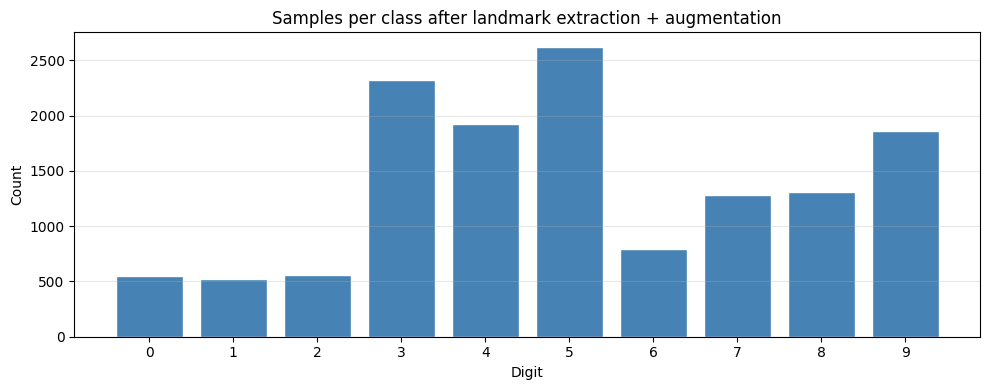

In [19]:
print(f'X shape : {X.shape}   (samples × 63 features)')
print(f'y shape : {y.shape}')
print(f'Classes : {num_classes}')

# Class distribution
unique, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([Digits[i] for i in unique], counts, color='steelblue', edgecolor='white')
ax.set_title('Samples per class after landmark extraction + augmentation')
ax.set_xlabel('Digit')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# One-hot encode labels
y_onehot = tf.keras.utils.to_categorical(y, num_classes)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_onehot,
    test_size    = val_split,
    random_state = SEED,
    stratify     = y,        # equal class distribution in both splits
)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')

Train : (10997, 63)
Val   : (2750, 63)


In [21]:
def build_mlp(input_size, num_classes):
    inputs = keras.Input(shape=(input_size,), name='landmarks')

    # Layer 1
    x = layers.Dense(512, use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.40)(x)

    # Layer 2
    x = layers.Dense(256, use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.35)(x)

    # Layer 3
    x = layers.Dense(128, use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.30)(x)

    # Output — 10 digits
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='ASL_Digits_MLP')


model = build_mlp(feature_size, num_classes)
model.summary(line_length=60)
print(f'\nTotal parameters: {model.count_params():,}')

Model: "ASL_Digits_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ landmarks (InputLayer)   │ (None, 63)        │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense (Dense)            │ (None, 512)       │    32,256 │
├──────────────────────────┼───────────────────┼───────────┤
│ batch_normalization      │ (None, 512)       │     2,048 │
│ (BatchNormalization)     │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ re_lu (ReLU)             │ (None, 512)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout (Dropout)        │ (None, 512)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_1 (Dense)          │ (None, 256)       │   131,072 │
├──────────────────────────┼───────────────────┼───────────┤
│ batch_normalization_1    │ (None, 256)       │     1,024 │
│ (BatchNormalization)     │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ re_lu_1 (ReLU)           │ (None, 256)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout_1 (Dropout)      │ (None, 256)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_2 (Dense)          │ (None, 128)       │    32,768 │
├──────────────────────────┼───────────────────┼───────────┤
│ batch_normalization_2    │ (None, 128)       │       512 │
│ (BatchNormalization)     │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ re_lu_2 (ReLU)           │ (None, 128)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout_2 (Dropout)      │ (None, 128)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_3 (Dense)          │ (None, 10)        │     1,290 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 200,970 (785.04 KB)

 Trainable params: 199,178 (778.04 KB)

 Non-trainable params: 1,792 (7.00 KB)


Total parameters: 200,970


In [22]:
model.compile(
    optimizer = keras.optimizers.Adam(LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    ModelCheckpoint(
        filepath       = model_save_path,
        monitor        = 'val_accuracy',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1,
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 15,
        restore_best_weights = True,
        mode                 = 'max',
        verbose              = 1,
    ),
    ReduceLROnPlateau(
        monitor  = 'val_accuracy',
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6,
        mode     = 'max',
        verbose  = 1,
    ),
]

t0 = time.time()

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = epochs,
    batch_size      = batch_size,
    callbacks       = callbacks,
    verbose         = 1,
)

print(f'\nTotal training time: {timedelta(seconds=int(time.time()-t0))}')

Epoch 1/100
35/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3917 - loss: 1.9915
Epoch 1: val_accuracy improved from None to 0.20582, saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5



Epoch 1: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6065 - loss: 1.3728 - val_accuracy: 0.2058 - val_loss: 1.9657 - learning_rate: 0.0010
Epoch 2/100
35/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7896 - loss: 0.7858
Epoch 2: val_accuracy improved from 0.20582 to 0.59345, saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5



Epoch 2: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8109 - loss: 0.7082 - val_accuracy: 0.5935 - val_loss: 1.5846 - learning_rate: 0.0010
Epoch 3/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8322 - loss: 0.6182
Epoch 3: val_accuracy did not improve from 0.59345
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8418 - loss: 0.5882 - val_accuracy: 0.5124 - val_loss: 1.4855 - learning_rate: 0.0010
Epoch 4/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8417 - loss: 0.5849
Epoch 4: val_accuracy did not improve from 0.59345
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8489 - loss: 0.5588 - val_accuracy: 0.5491 - val_loss: 1.4379 - learning_rate: 0.0010
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8491 - loss: 0.5417
Epoch 5: val_accuracy improved from 0.59345 to 0.61527, saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_


Epoch 5: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8571 - loss: 0.5204 - val_accuracy: 0.6153 - val_loss: 1.2958 - learning_rate: 0.0010
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8542 - loss: 0.5189
Epoch 6: val_accuracy improved from 0.61527 to 0.77782, saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5



Epoch 6: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8602 - loss: 0.5007 - val_accuracy: 0.7778 - val_loss: 1.0135 - learning_rate: 0.0010
Epoch 7/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8625 - loss: 0.4990
Epoch 7: val_accuracy improved from 0.77782 to 0.81527, saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5


...


Epoch 51: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9236 - loss: 0.2871 - val_accuracy: 0.9149 - val_loss: 0.3389 - learning_rate: 0.0010
Epoch 52/100
37/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9195 - loss: 0.2905
Epoch 52: val_accuracy did not improve from 0.91491
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9246 - loss: 0.2777 - val_accuracy: 0.9116 - val_loss: 0.3424 - learning_rate: 0.0010
Epoch 53/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9186 - loss: 0.3014
Epoch 53: val_accuracy did not improve from 0.91491
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9221 - loss: 0.2904 - val_accuracy: 0.9142 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 54/100
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9185 - loss: 0.2985
Epoch 54: val_accuracy did not improve from 0.91491
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9242 - loss: 0.2


Epoch 56: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9237 - loss: 0.2825 - val_accuracy: 0.9156 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 57/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9295 - loss: 0.2791
Epoch 57: val_accuracy did not improve from 0.91564
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9317 - loss: 0.2685 - val_accuracy: 0.9102 - val_loss: 0.3497 - learning_rate: 0.0010
Epoch 58/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9209 - loss: 0.2838
Epoch 58: val_accuracy did not improve from 0.91564
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9250 - loss: 0.2742 - val_accuracy: 0.9145 - val_loss: 0.3445 - learning_rate: 0.0010
Epoch 59/100
37/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9253 - loss: 0.2786
Epoch 59: val_accuracy did not improve from 0.91564
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9297 - loss: 0.2


Epoch 66: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9393 - loss: 0.2375 - val_accuracy: 0.9182 - val_loss: 0.3290 - learning_rate: 5.0000e-04
Epoch 67/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9374 - loss: 0.2420
Epoch 67: val_accuracy did not improve from 0.91818
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.2360 - val_accuracy: 0.9175 - val_loss: 0.3288 - learning_rate: 5.0000e-04
Epoch 68/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9312 - loss: 0.2468
Epoch 68: val_accuracy did not improve from 0.91818
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9375 - loss: 0.2321 - val_accuracy: 0.9167 - val_loss: 0.3307 - learning_rate: 5.0000e-04
Epoch 69/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9399 - loss: 0.2346
Epoch 69: val_accuracy did not improve from 0.91818
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9419


Epoch 79: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9509 - loss: 0.2044 - val_accuracy: 0.9211 - val_loss: 0.3368 - learning_rate: 2.5000e-04
Epoch 80/100
37/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9440 - loss: 0.2149
Epoch 80: val_accuracy did not improve from 0.92109
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9491 - loss: 0.2040 - val_accuracy: 0.9204 - val_loss: 0.3343 - learning_rate: 2.5000e-04
Epoch 81/100
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9434 - loss: 0.2190
Epoch 81: val_accuracy improved from 0.92109 to 0.92400, saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5



Epoch 81: finished saving model to C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9483 - loss: 0.2055 - val_accuracy: 0.9240 - val_loss: 0.3308 - learning_rate: 2.5000e-04
Epoch 82/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9475 - loss: 0.2118
Epoch 82: val_accuracy did not improve from 0.92400
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9494 - loss: 0.2028 - val_accuracy: 0.9218 - val_loss: 0.3314 - learning_rate: 2.5000e-04
Epoch 83/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9497 - loss: 0.2080
Epoch 83: val_accuracy did not improve from 0.92400
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9508 - loss: 0.2010 - val_accuracy: 0.9193 - val_loss: 0.3324 - learning_rate: 2.5000e-04
Epoch 84/100
37/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9464 - loss: 0.2063
Epoch 84: val_accuracy did not improve from 0.92400
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.951

In [7]:
import cv2
import numpy as np
import mediapipe as mp
from tensorflow.keras.models import load_model

# Load model
model = load_model(r"C:\Users\rrree\ASLproject\DigitsModel\digits_landmarks_model.h5")

# Mediapipe setup
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1)
mp_draw = mp.solutions.drawing_utils

# Labels (adjust if needed)
labels = [str(i) for i in range(10)]

def extract_landmarks(results):
    if results.multi_hand_landmarks:
        hand = results.multi_hand_landmarks[0]
        lm = []
        for point in hand.landmark:
            lm.extend([point.x, point.y, point.z])
        return np.array(lm)
    return None

def normalize_landmarks(landmarks):
    landmarks = landmarks.reshape(21, 3)
    landmarks = landmarks - landmarks[0]  # wrist normalization
    max_val = np.max(np.abs(landmarks))
    if max_val != 0:
        landmarks = landmarks / max_val
    return landmarks.flatten()

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        for handLms in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(frame, handLms, mp_hands.HAND_CONNECTIONS)

        landmarks = extract_landmarks(results)

        if landmarks is not None:
            landmarks = normalize_landmarks(landmarks)
            landmarks = np.expand_dims(landmarks, axis=0)

            prediction = model.predict(landmarks, verbose=0)
            class_id = np.argmax(prediction)
            confidence = np.max(prediction)

            text = f"{labels[class_id]} ({confidence:.2f})"

            cv2.putText(frame, text, (10, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1,
                        (0, 255, 0), 2)

    cv2.imshow("Hand Gesture Recognition", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()